# 04 — Radius-cut comparison: within $1\,R_{200c}$ vs all radii (overlaid)

Same open catalog and machinery as `03_analyze_flexible.ipynb`, but instead of a single radius
setting it **overlays two radius selections on top of each other** for each simulation:

* **within $R_{200c}$** — `d_r200_3d < R200C_FACTOR` (solid line / circles), and
* **all radii** — no radius cut (dashed line / squares).

Everything else stays flexible: host-mass window (`HOST_WINDOW`), redshift (`REDZ`), and the
per-simulation satellite cut (`PANELS`). Defaults: host $12.0<\log M_{200c}<12.5$, z = 0,
TNG100 $>10^8$, TNG50 $>10^7$, aperture $1\,R_{200c}$.

Two figures, each a TNG100 | TNG50 pair with both radius variants overlaid:
1. **anisotropy** $p(\theta)\propto 1+A\cos2\theta$, and
2. **quench fraction** $f_q(\theta)=a+b\cos2\theta$.

> Change `R200C_FACTOR` to compare a different aperture against "all radii", or edit `HOST_WINDOW`
> / `REDZ` / `PANELS`. Missing catalogs are skipped with a warning.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import emcee
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})

# ================= CONFIG — change these and re-run =================
DATA_ROOT = "../data2"
BASE_CAT  = "tng_satellites_hostlogM12.0plus_logM7.00.csv"   # open catalog from 01_generate_catalogs_massive

REDZ         = "z0"            # "z0" (z=0) or "z0p05" (z=0.05)
HOST_WINDOW  = (12.0, 12.5)    # host log10(M200c) window (min, max); None on either end = open
R200C_FACTOR = 1.0            # the finite aperture (in R_200c) compared against "all radii"

# what each panel shows: (sim, satellite log10 M* cut, color)
PANELS = [
    ("tng100", 8.0, "#1f77b4"),   # TNG100: M*_sat > 1e8
    ("tng50",  7.0, "#d62728"),   # TNG50:  M*_sat > 1e7
]
# the two radius selections to overlay: (label, factor or None, linestyle, marker)
RADIUS_VARIANTS = [
    (f"within {R200C_FACTOR:g} R200c", R200C_FACTOR, "-",  "o"),
    ("all radii",                      None,         "--", "s"),
]
# ===================================================================

# 18 angle bins over [0, 90]
N_BINS        = 18
ANGLE_EDGES   = np.linspace(0, 90, N_BINS + 1)
ANGLE_CENTERS = 0.5 * (ANGLE_EDGES[:-1] + ANGLE_EDGES[1:])

def _host_str(w):
    lo, hi = w
    if lo is not None and hi is not None: return f"{lo:.1f} < logM200c < {hi:.1f}"
    if lo is not None:                    return f"logM200c > {lo:.1f}"
    if hi is not None:                    return f"logM200c < {hi:.1f}"
    return "all hosts"

print(f"host window: {_host_str(HOST_WINDOW)} | z: {REDZ} | comparing "
      f"'within {R200C_FACTOR:g} R200c' vs 'all radii'")

host window: 12.0 < logM200c < 12.5 | z: z0 | comparing 'within 1 R200c' vs 'all radii'


## Helpers — $P(\theta)$, the $A$ fit, and the quench-fraction sinusoid

Identical to `notebooks2/02` and `03`.

In [2]:
def norm_hist(theta):
    c, _ = np.histogram(theta, bins=ANGLE_EDGES)
    return c / c.sum() / (90.0 / N_BINS)

def model_curve(A):
    x = np.linspace(0, 90, 200)
    return x, (1.0 / 90.0) * (1.0 + A * np.cos(2 * np.radians(x)))

def fit_anisotropy(theta_deg, n_walkers=16, n_steps=4000, burn=1000, seed=0):
    '''MCMC of p(theta) ~ 1 + A cos(2 theta). Returns dict with A median/std/percentiles.'''
    th = np.radians(np.asarray(theta_deg, dtype=float))
    c2 = np.cos(2 * th); n = len(th)
    if n < 5:
        return dict(n=n, A=np.nan, Aerr=np.nan, lo=np.nan, hi=np.nan)

    def log_prob(p):
        A = p[0]
        if not (-0.999 < A < 0.999):
            return -np.inf
        v = 1.0 + A * c2
        if np.any(v <= 0):
            return -np.inf
        return np.sum(np.log(v))

    rng = np.random.default_rng(seed)
    p0 = rng.uniform(-0.1, 0.1, size=(n_walkers, 1))
    sampler = emcee.EnsembleSampler(n_walkers, 1, log_prob)
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)[:, 0]
    lo, med, hi = np.percentile(chain, [16, 50, 84])
    return dict(n=n, A=med, Aerr=chain.std(), lo=lo, hi=hi)

def bootstrap_fq(angle, quenched, N=5000, seed=0):
    '''Binned-mean quench fraction per angle bin, bootstrap mean and 1-sigma error.'''
    rng = np.random.default_rng(seed)
    angle = np.asarray(angle); quenched = np.asarray(quenched, dtype=float)
    n = len(angle)
    boot = np.full((N, N_BINS), np.nan)
    bin_idx = np.digitize(angle, ANGLE_EDGES) - 1
    for i in range(N):
        s = rng.integers(0, n, n)
        bi, qi = bin_idx[s], quenched[s]
        for j in range(N_BINS):
            m = bi == j
            if m.any():
                boot[i, j] = qi[m].mean()
    return np.nanmean(boot, axis=0), np.nanstd(boot, axis=0)

def _fq_log_prob(theta, x, y, sigma):
    a, b, f = theta
    if not (0 < a < 1 and -1 < b < 1 and -10 < f < 2):
        return -np.inf
    s = sigma ** 2 + np.exp(f) ** 2
    model = a + b * np.cos(2 * np.radians(x))
    return -0.5 * np.sum((y - model) ** 2 / s + np.log(2 * np.pi * s))

def fit_fq_sinusoid(mean, std, n_walkers=20, n_steps=6000, burn=1000, seed=0):
    '''MCMC fit of f_q = a + b cos(2 theta); returns (params_mean, params_std).'''
    np.random.seed(seed)
    ok = np.isfinite(mean) & np.isfinite(std) & (std > 0)
    if ok.sum() < 4:
        return np.array([np.nan] * 3), np.array([np.nan] * 3)
    p0 = np.array([0.5, 0.0, -3.0]) + 1e-2 * np.random.randn(n_walkers, 3)
    sampler = emcee.EnsembleSampler(n_walkers, 3, _fq_log_prob,
                                    args=(ANGLE_CENTERS[ok], mean[ok], std[ok]))
    sampler.run_mcmc(p0, n_steps, progress=False)
    chain = sampler.get_chain(discard=burn, flat=True)
    return chain.mean(axis=0), chain.std(axis=0)

def fq_band(p, e, n_mc=5000, seed=0):
    '''Posterior median + 16/84th-percentile band of f_q over [0, 90].'''
    rng = np.random.default_rng(seed)
    x = np.linspace(0, np.pi / 2, 300)
    a = rng.normal(p[0], e[0], n_mc); b = rng.normal(p[1], e[1], n_mc)
    yy = a[:, None] + b[:, None] * np.cos(2 * x)[None, :]
    return np.degrees(x), a.mean() + b.mean() * np.cos(2 * x), np.percentile(yy, 16, 0), np.percentile(yy, 84, 0)

## Load both radius variants for every simulation

For each `(sim, radius variant)` we read the one open catalog for `REDZ`, apply the `HOST_WINDOW`
and the panel's satellite floor, then either keep `d_r200_3d < R200C_FACTOR` (the finite aperture)
or nothing (all radii). Keys are `(sim, variant-label)`.

In [3]:
def load_sel(sim, logcut, rfactor):
    path = os.path.join(DATA_ROOT, sim, REDZ, BASE_CAT)
    if not os.path.exists(path):
        print(f"[skip] missing {path}")
        return None
    df = pd.read_csv(path)
    hlo, hhi = HOST_WINDOW
    if hlo is not None: df = df[df["host_m200_phys"] > hlo]
    if hhi is not None: df = df[df["host_m200_phys"] < hhi]
    df = df[df["mstar_phys"] > logcut]
    if rfactor is not None:
        df = df[df["d_r200_3d"] < rfactor]
    return df

data, quench, fits, fq_mean, fq_std, fq_p, fq_e = {}, {}, {}, {}, {}, {}, {}
print(f"{'dataset':<10s} {'radius':<16s} {'sats':>7s} {'f_q':>7s}")
for sim, logcut, _ in PANELS:
    for vlabel, rfac, _, _ in RADIUS_VARIANTS:
        df = load_sel(sim, logcut, rfac)
        if df is None or len(df) == 0:
            continue
        key = (sim, vlabel)
        data[key]   = df["alpha"].to_numpy()
        quench[key] = df["quenched"].to_numpy(dtype=float)
        fits[key]   = fit_anisotropy(data[key], seed=1)
        m, s = bootstrap_fq(data[key], quench[key])
        fq_mean[key], fq_std[key] = m, s
        fq_p[key], fq_e[key] = fit_fq_sinusoid(m, s)
        print(f"{sim:<10s} {vlabel:<16s} {len(df):>7d} {df['quenched'].mean():>7.3f}")

dataset    radius              sats     f_q
tng100     within 1 R200c      2165   0.364
tng100     all radii           3198   0.315
tng50      within 1 R200c       945   0.580
tng50      all radii           1384   0.563


## Fit summary — how the radius cut moves $A$ and $b$

For each simulation, compare the within-$R_{200c}$ row against the all-radii row.

In [5]:
print(f"{'dataset':<10s} {'radius':<16s} {'N':>6s}  {'A':>15s}  {'b':>15s}  |b|/sig")
for sim, logcut, _ in PANELS:
    for vlabel, rfac, _, _ in RADIUS_VARIANTS:
        key = (sim, vlabel)
        if key not in fits:
            continue
        f = fits[key]; p, e = fq_p[key], fq_e[key]
        bsig = abs(p[1] / e[1]) if np.isfinite(p[1]) else np.nan
        print(f"{sim:<10s} {vlabel:<16s} {f['n']:>6d}  {f['A']:+.3f}+/-{f['Aerr']:.3f}  "
              f"{p[1]:+.3f}+/-{e[1]:.3f}  {bsig:.2f}")

dataset    radius                N                A                b  |b|/sig
tng100     within 1 R200c     2165  +0.222+/-0.029  -0.038+/-0.015  2.54
tng100     all radii          3198  +0.186+/-0.025  -0.027+/-0.012  2.23
tng50      within 1 R200c      945  +0.189+/-0.046  -0.057+/-0.023  2.45
tng50      all radii          1384  +0.156+/-0.038  -0.058+/-0.019  2.97


### Figure 1 — anisotropy $P(\theta)$: within $R_{200c}$ (solid) vs all radii (dashed)

Overlaid per simulation. Stepped histogram = $P(\theta)$; smooth curve = posterior-median
$\tfrac{1}{90}(1+A\cos2\theta)$; dotted line = isotropic level.

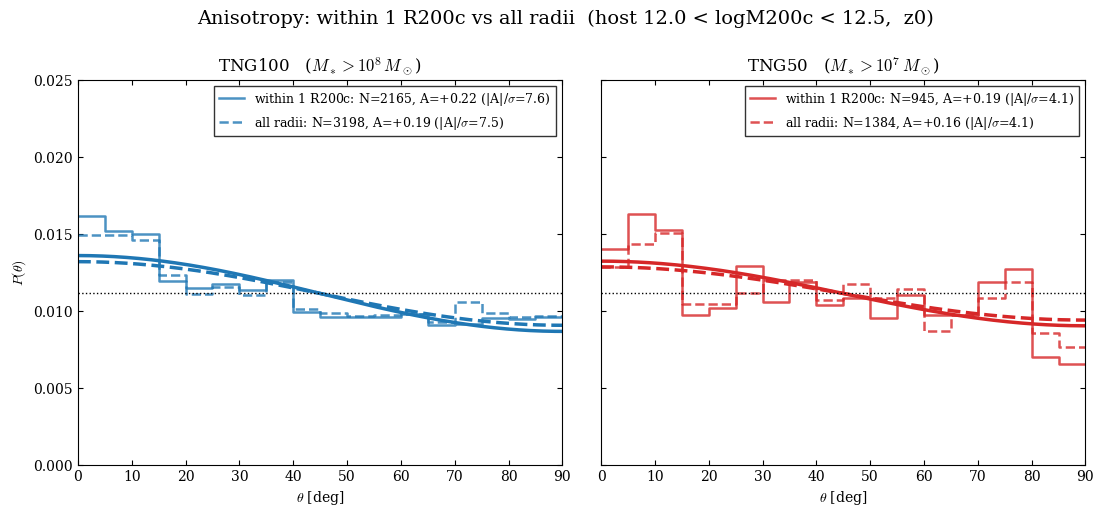

In [6]:
SATLABEL = {8.0: r"$M_* > 10^8\,M_\odot$", 7.0: r"$M_* > 10^7\,M_\odot$"}
_sup = f"host {_host_str(HOST_WINDOW)},  {REDZ}"

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (sim, logcut, color) in zip(axes, PANELS):
    for vlabel, rfac, ls, marker in RADIUS_VARIANTS:
        key = (sim, vlabel)
        if key not in fits:
            continue
        f = fits[key]; h = norm_hist(data[key])
        ax.step(ANGLE_EDGES, np.r_[h, h[-1]], where="post", color=color, ls=ls, lw=1.8, alpha=0.8,
                label=f"{vlabel}: N={f['n']}, A={f['A']:+.2f} (|A|/$\\sigma$={abs(f['A']/f['Aerr']):.1f})")
        if np.isfinite(f["A"]):
            x, y = model_curve(f["A"]); ax.plot(x, y, color=color, ls=ls, lw=2.5)
    ax.axhline(1 / 90, color="k", lw=1, ls=":")
    ax.set_xlim(0, 90); ax.set_ylim(0, 0.025)
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_title(f"{sim.upper()}   ({SATLABEL.get(logcut, '')})")
    ax.legend(fontsize=9, fancybox=False, edgecolor="k")
    ax.tick_params(which="both", direction="in", top=True, right=True)
axes[0].set_ylabel(r"$P(\theta)$")
fig.suptitle(f"Anisotropy: within {R200C_FACTOR:g} R200c vs all radii  ({_sup})", y=1.02, fontsize=14)
plt.subplots_adjust(wspace=0.08); plt.show()

### Figure 2 — quench fraction $f_q(\theta)$: within $R_{200c}$ (circles/solid) vs all radii (squares/dashed)

Overlaid per simulation. Points + error bars = bootstrap $f_q$; line + band = MCMC posterior
median and 16-84th percentile.

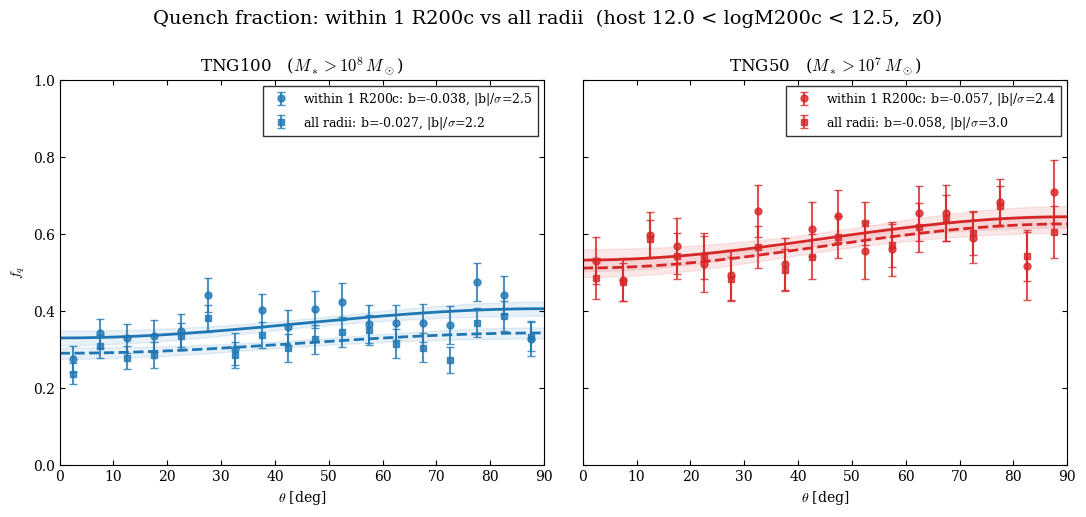

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (sim, logcut, color) in zip(axes, PANELS):
    for vlabel, rfac, ls, marker in RADIUS_VARIANTS:
        key = (sim, vlabel)
        if key not in fq_p:
            continue
        m, s = fq_mean[key], fq_std[key]
        p, e = fq_p[key], fq_e[key]
        sig = abs(p[1] / e[1]) if np.isfinite(p[1]) else np.nan
        ax.errorbar(ANGLE_CENTERS, m, yerr=s, fmt=marker, color=color, capsize=3, ms=5, ls="none",
                    alpha=0.8, label=f"{vlabel}: b={p[1]:+.3f}, |b|/$\\sigma$={sig:.1f}")
        if np.isfinite(p[1]):
            x, ymed, ylo, yhi = fq_band(p, e)
            ax.plot(x, ymed, color=color, ls=ls, lw=2)
            ax.fill_between(x, ylo, yhi, color=color, alpha=0.10)
    ax.set_xlim(0, 90); ax.set_ylim(0, 1)
    ax.set_xlabel(r"$\theta$ [deg]")
    ax.set_title(f"{sim.upper()}   ({SATLABEL.get(logcut, '')})")
    ax.legend(fontsize=9, fancybox=False, edgecolor="k")
    ax.tick_params(which="both", direction="in", top=True, right=True)
axes[0].set_ylabel(r"$f_q$")
fig.suptitle(f"Quench fraction: within {R200C_FACTOR:g} R200c vs all radii  ({_sup})", y=1.02, fontsize=14)
plt.subplots_adjust(wspace=0.08); plt.show()